# 3CSD Group 8 Implementation — Self-Contained Version

**Evaluating Algorithmic Bias and Feature Thresholds in Predicting Geopolitical Attack Success Using Logistic Regression, CART, XGBoost, and a Feedforward Neural Network on the Global Terrorism Database**

This version is designed for submission as a standalone notebook. It includes the helper pipeline code directly in the notebook, so it does **not** require the `src/` folder. It still requires the raw GTD files in `data/raw/` and the packages listed in `requirements.txt`. (This is because the notebook was based of the repository, we created this for the submission requirement via Canvas.)

GitHub Repository: https://github.com/Shrxmy/CSELEC2C-FinalProject


## 1. Setup and Reproducibility

This self-contained notebook can be run from the project root or from `notebooks/`. The helper functions that were previously imported from `src/gtd_pipeline.py` are included directly in the setup cell below.


In [1]:
from pathlib import Path
from types import SimpleNamespace
import random, sys, joblib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, f1_score, matthews_corrcoef, precision_score, recall_score, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
try:
    import torch
    from torch import nn
except ImportError:
    torch, nn = None, None

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

USE_SAMPLE = False          # True = quick smoke test, False = final manuscript run.
SAMPLE_NROWS = 5000
REBUILD_DATA_CACHE = False  # True only if raw files changed.
USE_GPU = True              # PyTorch using CUDA
RUN_SHAP = True             # SHAP explanations (can be slow, especially without GPU)
SHAP_SAMPLE_SIZE = 1500

# This area was assisted via AI code generation, but has been reviewed and edited by the team to ensure accuracy and relevance to our project goals.
# The main purpose of this area of code is to load, preprocess, and model the GTD dataset, as well as to evaluate model performance and conduct error analysis.
TARGET = "success"
ID_COLUMN = "eventid"
NUMERIC_FEATURES = ["iyear", "imonth", "iday", "extended", "latitude", "longitude", "specificity", "vicinity", "doubtterr", "multiple", "suicide", "guncertain1", "individual", "claimed", "INT_LOG", "INT_IDEO", "INT_MISC", "INT_ANY"]
CATEGORICAL_FEATURES = ["region_txt", "country_txt", "attacktype1_txt", "targtype1_txt", "targsubtype1_txt", "natlty1_txt", "weaptype1_txt", "weapsubtype1_txt"]
LEAKAGE_COLUMNS_EXCLUDED = ["nkill", "nkillus", "nkillter", "nwound", "nwoundus", "nwoundte", "property", "propextent", "propextent_txt", "propvalue", "ransom", "ransomamt", "ransompaid", "hostkidoutcome", "hostkidoutcome_txt", "nreleased"]

def _resolve_required_file(raw_dir, stems, label):
    for stem in stems:
        for ext in [".xlsx", ".xls", ".csv", ".parquet"]:
            p = raw_dir / f"{stem}{ext}"
            if p.exists():
                return p
    raise FileNotFoundError(f"Missing {label}. Place one of {[s+e for s in stems for e in ['.xlsx','.xls','.csv','.parquet']]} in {raw_dir}")

def get_project_paths(root=None):
    root = Path.cwd() if root is None else Path(root)
    if root.name.lower() == "notebooks":
        root = root.parent
    raw = root / "data" / "raw"
    processed = root / "data" / "processed"
    models = root / "models"
    figs = root / "results" / "figures"
    tabs = root / "results" / "tables"
    for d in [raw, processed, models, figs, tabs]:
        d.mkdir(parents=True, exist_ok=True)
    return SimpleNamespace(
        root=root, raw_dir=raw, processed_dir=processed, models_dir=models, figures_dir=figs, tables_dir=tabs,
        main_file=_resolve_required_file(raw, ["globalterrorismdb_0522dist", "globalterrorismdb", "gtd"], "main GTD dataset"),
        supplement_2021_file=_resolve_required_file(raw, ["globalterrorismdb_2021Jan-June_1222dist", "gtd_2021Jan-June", "gtd_2021"], "2021 supplement"),
        cache_file=processed / "gtd_combined_cleaned.parquet",
    )

def requested_columns():
    return list(dict.fromkeys([ID_COLUMN] + NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]))

def read_table(path, usecols, nrows=None):
    suffix = path.suffix.lower()
    if suffix in {".xlsx", ".xls"}:
        cols = pd.read_excel(path, nrows=0).columns.tolist()
        return pd.read_excel(path, usecols=[c for c in usecols if c in cols], nrows=nrows)
    if suffix == ".csv":
        cols = pd.read_csv(path, nrows=0).columns.tolist()
        return pd.read_csv(path, usecols=[c for c in usecols if c in cols], nrows=nrows, low_memory=False)
    if suffix == ".parquet":
        cols = pd.read_parquet(path, columns=None).head(0).columns.tolist()
        df = pd.read_parquet(path, columns=[c for c in usecols if c in cols])
        return df.head(nrows) if nrows else df
    raise ValueError(f"Unsupported file type: {path.suffix}")

def load_gtd(paths, use_cache=True, sample_nrows=None):
    if use_cache and sample_nrows is None and paths.cache_file.exists():
        return pd.read_parquet(paths.cache_file)
    usecols = requested_columns()
    main = read_table(paths.main_file, usecols, sample_nrows)
    supp = read_table(paths.supplement_2021_file, usecols, None if sample_nrows is None else sample_nrows)
    main["source_file"], supp["source_file"] = paths.main_file.name, paths.supplement_2021_file.name
    raw = pd.concat([main, supp], ignore_index=True).drop_duplicates(subset=ID_COLUMN, keep="first")
    raw = raw[raw[TARGET].isin([0, 1])].copy().reset_index(drop=True)
    for c in [x for x in NUMERIC_FEATURES if x in raw.columns]:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
    for c in [x for x in CATEGORICAL_FEATURES if x in raw.columns]:
        raw[c] = raw[c].astype("string").fillna("Unknown")
    if sample_nrows is None:
        raw.to_parquet(paths.cache_file, index=False)
    return raw

def make_xy(df):
    numeric = [c for c in NUMERIC_FEATURES if c in df.columns]
    categorical = [c for c in CATEGORICAL_FEATURES if c in df.columns]
    return df[numeric + categorical].copy(), df[TARGET].astype(int).copy(), numeric, categorical

def temporal_split(X, y, train_end=2014, valid_end=2017):
    tr = X["iyear"] <= train_end
    va = (X["iyear"] > train_end) & (X["iyear"] <= valid_end)
    te = X["iyear"] > valid_end
    if min(tr.sum(), va.sum(), te.sum()) == 0:
        raise ValueError("Temporal split produced an empty partition.")
    return X.loc[tr].copy(), X.loc[va].copy(), X.loc[te].copy(), y.loc[tr].copy(), y.loc[va].copy(), y.loc[te].copy()

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20, sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

def make_preprocessor(numeric, categorical):
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")), ("onehot", make_one_hot_encoder())]), categorical),
    ], remainder="drop", sparse_threshold=0.3)

class TorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layers=(128, 64), lr=1e-3, weight_decay=1e-4, batch_size=512, max_epochs=30, patience=5, use_gpu=True, random_state=42, verbose=True):
        self.hidden_layers, self.lr, self.weight_decay, self.batch_size, self.max_epochs, self.patience, self.use_gpu, self.random_state, self.verbose = hidden_layers, lr, weight_decay, batch_size, max_epochs, patience, use_gpu, random_state, verbose
    def _device(self):
        return torch.device("cuda" if self.use_gpu and torch is not None and torch.cuda.is_available() else "cpu")
    def _build_network(self, input_dim):
        layers, prev = [], input_dim
        for h in self.hidden_layers:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(0.20)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        return nn.Sequential(*layers)
    def _to_tensor(self, Xb):
        if sparse.issparse(Xb):
            Xb = Xb.toarray()
        return torch.as_tensor(Xb, dtype=torch.float32, device=self.device_)
    def fit(self, X, y):
        if torch is None:
            raise ImportError("PyTorch is required for TorchMLPClassifier")
        torch.manual_seed(self.random_state)
        rng = np.random.default_rng(self.random_state)
        self.classes_, self.device_ = np.array([0, 1]), self._device()
        self.device_name_ = str(self.device_)
        y_arr = np.asarray(y).astype(np.float32)
        self.network_ = self._build_network(X.shape[1]).to(self.device_)
        idx = np.arange(X.shape[0]); rng.shuffle(idx)
        v = max(int(0.10 * len(idx)), 1); valid_idx, train_idx = idx[:v], idx[v:]
        pos, neg = max(float((y_arr[train_idx] == 1).sum()), 1.0), max(float((y_arr[train_idx] == 0).sum()), 1.0)
        crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg / pos], device=self.device_))
        opt = torch.optim.AdamW(self.network_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        best_state, best_loss, stale = None, float("inf"), 0
        for epoch in range(1, self.max_epochs + 1):
            self.network_.train(); rng.shuffle(train_idx); losses = []
            for start in range(0, len(train_idx), self.batch_size):
                batch = train_idx[start:start+self.batch_size]
                xb = self._to_tensor(X[batch]); yb = torch.as_tensor(y_arr[batch], dtype=torch.float32, device=self.device_).view(-1, 1)
                opt.zero_grad(set_to_none=True); loss = crit(self.network_(xb), yb); loss.backward(); opt.step()
                losses.append(float(loss.detach().cpu()))
            val_loss = self._validation_loss(X, y_arr, valid_idx, crit)
            if self.verbose and (epoch == 1 or epoch % 5 == 0):
                print(f"Torch NN epoch {epoch:02d} | train_loss={np.mean(losses):.4f} | valid_loss={val_loss:.4f}")
            if val_loss < best_loss:
                best_loss, stale = val_loss, 0
                best_state = {k: v.detach().cpu().clone() for k, v in self.network_.state_dict().items()}
            else:
                stale += 1
                if stale >= self.patience:
                    break
        if best_state:
            self.network_.load_state_dict(best_state); self.network_.to(self.device_)
        return self
    def _validation_loss(self, X, y_arr, valid_idx, crit):
        self.network_.eval(); losses = []
        with torch.no_grad():
            for start in range(0, len(valid_idx), self.batch_size):
                batch = valid_idx[start:start+self.batch_size]
                xb = self._to_tensor(X[batch]); yb = torch.as_tensor(y_arr[batch], dtype=torch.float32, device=self.device_).view(-1, 1)
                losses.append(float(crit(self.network_(xb), yb).detach().cpu()))
        return float(np.mean(losses)) if losses else float("inf")
    def predict_proba(self, X):
        self.network_.eval(); probs = []
        with torch.no_grad():
            for start in range(0, X.shape[0], self.batch_size):
                logits = self.network_(self._to_tensor(X[start:start+self.batch_size]))
                probs.extend(torch.sigmoid(logits).detach().cpu().numpy().ravel())
        probs = np.asarray(probs)
        return np.column_stack([1 - probs, probs])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
    def save_torch_state(self, path):
        torch.save({"state_dict": self.network_.state_dict(), "hidden_layers": self.hidden_layers, "device": self.device_name_}, path)

def build_models(numeric, categorical, y_train, use_gpu=True, random_state=RANDOM_STATE):
    pre = lambda: make_preprocessor(numeric, categorical)
    models = {"logistic_regression": Pipeline([("preprocessor", pre()), ("model", LogisticRegression(class_weight="balanced", max_iter=2000, solver="saga", random_state=random_state))])}
    if XGBClassifier is not None:
        pos, neg = max(int((y_train == 1).sum()), 1), max(int((y_train == 0).sum()), 1)
        device = "cuda" if use_gpu and torch is not None and torch.cuda.is_available() else "cpu"
        models["xgboost"] = Pipeline([("preprocessor", pre()), ("model", XGBClassifier(n_estimators=350, max_depth=4, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, objective="binary:logistic", eval_metric="logloss", scale_pos_weight=neg/pos, random_state=random_state, n_jobs=-1, tree_method="hist", device=device))])
    models["feedforward_torch_nn"] = Pipeline([("preprocessor", pre()), ("model", TorchMLPClassifier(use_gpu=use_gpu, random_state=random_state, verbose=True))])
    return models

def train_models(models, X_train, y_train, paths):
    for name, model in models.items():
        print(f"Training {name}..."); model.fit(X_train, y_train)
        if name == "feedforward_torch_nn":
            joblib.dump(model.named_steps["preprocessor"], paths.models_dir / "feedforward_torch_preprocessor.joblib")
            model.named_steps["model"].save_torch_state(paths.models_dir / "feedforward_torch_nn.pt")
        else:
            joblib.dump(model, paths.models_dir / f"{name}.joblib")
    return models

def predict_proba_positive(model, X):
    return model.predict_proba(X)[:, 1]

def metrics_at_threshold(y_true, proba, threshold=0.5):
    y_true = np.asarray(y_true).astype(int); pred = (np.asarray(proba) >= threshold).astype(int)
    fp = int(((pred == 1) & (y_true == 0)).sum()); fn = int(((pred == 0) & (y_true == 1)).sum())
    tp = int(((pred == 1) & (y_true == 1)).sum()); tn = int(((pred == 0) & (y_true == 0)).sum())
    return {"threshold": threshold, "accuracy": accuracy_score(y_true, pred), "balanced_accuracy": balanced_accuracy_score(y_true, pred), "precision": precision_score(y_true, pred, zero_division=0), "recall": recall_score(y_true, pred, zero_division=0), "f1": f1_score(y_true, pred, zero_division=0), "false_positive_rate": fp/(fp+tn) if fp+tn else 0.0, "false_negative_rate": fn/(fn+tp) if fn+tp else 0.0, "tp": tp, "fp": fp, "tn": tn, "fn": fn}

def robust_metrics(model_name, split_name, y_true, proba, threshold=0.5):
    row = {"model": model_name, "split": split_name, "roc_auc": roc_auc_score(y_true, proba), "average_precision_success": average_precision_score(y_true, proba), "average_precision_failure": average_precision_score(1-np.asarray(y_true), 1-np.asarray(proba)), "brier_score": brier_score_loss(y_true, proba)}
    row.update(metrics_at_threshold(y_true, proba, threshold)); row["mcc"] = matthews_corrcoef(np.asarray(y_true), (np.asarray(proba) >= threshold).astype(int))
    return row

def evaluate_models(models, X_valid, y_valid, X_test, y_test):
    return pd.DataFrame([robust_metrics(name, split, ys, predict_proba_positive(model, Xs), 0.5) for split, Xs, ys in [("validation", X_valid, y_valid), ("test", X_test, y_test)] for name, model in models.items()])

def threshold_simulation(models, X_test, y_test, thresholds=(0.30, 0.40, 0.50, 0.60, 0.70)):
    rows = []
    for name, model in models.items():
        p = predict_proba_positive(model, X_test)
        for t in thresholds:
            row = {"model": name, "split": "test"}; row.update(metrics_at_threshold(y_test, p, t)); rows.append(row)
    return pd.DataFrame(rows)

def select_validation_thresholds(models, X_valid, y_valid, X_test, y_test, grid=None):
    grid = np.round(np.arange(0.20, 0.81, 0.01), 2) if grid is None else grid
    rows = []
    for name, model in models.items():
        vp = predict_proba_positive(model, X_valid)
        cand = [{"model": name, "split": "validation", **metrics_at_threshold(y_valid, vp, float(t))} for t in grid]
        best = pd.DataFrame(cand).sort_values(["balanced_accuracy", "f1"], ascending=False).iloc[0]
        rows.append(best.to_dict())
        tp = predict_proba_positive(model, X_test)
        row = {"model": name, "split": "test_selected_validation_threshold"}; row.update(metrics_at_threshold(y_test, tp, float(best.threshold))); rows.append(row)
    return pd.DataFrame(rows)

def subgroup_error_analysis(name, model, X, y, subgroup_cols, threshold=0.5, min_n=50):
    proba = predict_proba_positive(model, X); pred = (proba >= threshold).astype(int)
    tmp = X[subgroup_cols].copy(); tmp["y"] = np.asarray(y); tmp["pred"] = pred
    rows = []
    for col in subgroup_cols:
        for group, g in tmp.groupby(col, dropna=False):
            n = len(g)
            if n < min_n: continue
            yv, pv = g["y"].to_numpy(), g["pred"].to_numpy()
            fp = ((pv == 1) & (yv == 0)).sum(); tn = ((pv == 0) & (yv == 0)).sum(); fn = ((pv == 0) & (yv == 1)).sum(); tp = ((pv == 1) & (yv == 1)).sum()
            rows.append({"model": name, "subgroup_column": col, "group": str(group), "n": n, "base_success_rate": yv.mean(), "false_positive_rate": fp/(fp+tn) if fp+tn else np.nan, "false_negative_rate": fn/(fn+tp) if fn+tp else np.nan, "tp": tp, "fp": fp, "tn": tn, "fn": fn})
    return pd.DataFrame(rows)

def plot_roc_pr_curves(models, X_test, y_test, figures_dir):
    from sklearn.metrics import precision_recall_curve, roc_curve
    plt.figure(figsize=(7, 5))
    for name, model in models.items():
        p = predict_proba_positive(model, X_test); fpr, tpr, _ = roc_curve(y_test, p)
        plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc_score(y_test, p):.3f}")
    plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1); plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.legend(); plt.tight_layout(); plt.savefig(figures_dir / "roc_curves_test.png", dpi=180); plt.show()
    plt.figure(figsize=(7, 5))
    for name, model in models.items():
        p = predict_proba_positive(model, X_test); precision, recall, _ = precision_recall_curve(y_test, p)
        plt.plot(recall, precision, label=f"{name} AP={average_precision_score(y_test, p):.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.tight_layout(); plt.savefig(figures_dir / "precision_recall_curves_test.png", dpi=180); plt.show()

def save_table(df, path):
    df.to_csv(path, index=False)
    return df

# Pipleining ends here. Below is the execution area that runs the above code to load data, train models, and evaluate them.

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
paths = get_project_paths(PROJECT_ROOT)
print("Project root:", paths.root)
print("Raw data directory:", paths.raw_dir)
print("Main GTD file:", paths.main_file)
print("Mandatory 2021 supplement:", paths.supplement_2021_file)
print("Processed cache:", paths.cache_file)


Project root: c:\Documents\Compsci\CSELEC2C\Project
Raw data directory: c:\Documents\Compsci\CSELEC2C\Project\data\raw
Main GTD file: c:\Documents\Compsci\CSELEC2C\Project\data\raw\globalterrorismdb_0522dist.xlsx
Mandatory 2021 supplement: c:\Documents\Compsci\CSELEC2C\Project\data\raw\globalterrorismdb_2021Jan-June_1222dist.xlsx
Processed cache: c:\Documents\Compsci\CSELEC2C\Project\data\processed\gtd_combined_cleaned.parquet


## 2. Modeling Assumptions and Feature Set

The target is GTD `success`. To reduce target leakage, casualty, property-damage, ransom, and hostage-outcome fields are excluded because they are consequences or post-event descriptors. The retained features are temporal, geopolitical, tactical, target, weapon, uncertainty, and claim-related fields.

In [2]:
print("Target:", TARGET)
print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print("Excluded leakage columns:", LEAKAGE_COLUMNS_EXCLUDED)

Target: success
Numeric features: ['iyear', 'imonth', 'iday', 'extended', 'latitude', 'longitude', 'specificity', 'vicinity', 'doubtterr', 'multiple', 'suicide', 'guncertain1', 'individual', 'claimed', 'INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY']
Categorical features: ['region_txt', 'country_txt', 'attacktype1_txt', 'targtype1_txt', 'targsubtype1_txt', 'natlty1_txt', 'weaptype1_txt', 'weapsubtype1_txt']
Excluded leakage columns: ['nkill', 'nkillus', 'nkillter', 'nwound', 'nwoundus', 'nwoundte', 'property', 'propextent', 'propextent_txt', 'propvalue', 'ransom', 'ransomamt', 'ransompaid', 'hostkidoutcome', 'hostkidoutcome_txt', 'nreleased']


## 3. Load, Clean, Cache, and Split Data

Both GTD files are mandatory. The main file and the 2021 supplement are combined, deduplicated by `eventid`, cleaned, then split temporally:

- Train: 1970–2014
- Validation: 2015–2017
- Test: 2018 onward

In [3]:
sample_nrows = SAMPLE_NROWS if USE_SAMPLE else None
if REBUILD_DATA_CACHE and paths.cache_file.exists():
    paths.cache_file.unlink()

df = load_gtd(paths, use_cache=not REBUILD_DATA_CACHE, sample_nrows=sample_nrows)
X, y, numeric_features, categorical_features = make_xy(df)
X_train, X_valid, X_test, y_train, y_valid, y_test = temporal_split(X, y)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_valid), len(X_test)],
    "start_year": [int(X_train.iyear.min()), int(X_valid.iyear.min()), int(X_test.iyear.min())],
    "end_year": [int(X_train.iyear.max()), int(X_valid.iyear.max()), int(X_test.iyear.max())],
    "success_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
})

class_balance = y.value_counts(normalize=True).rename("proportion").to_frame()
class_balance["count"] = y.value_counts()

print("Raw/cleaned shape:", df.shape)
print("Year range:", int(df.iyear.min()), "to", int(df.iyear.max()))
display(split_summary)
display(class_balance)

Raw/cleaned shape: (214666, 29)
Year range: 1970 to 2021


,split,n,start_year,end_year,success_rate
0,train,142325,1970,2014,0.909229
1,validation,40553,2015,2017,0.818706
2,test,31788,2018,2021,0.846829


,proportion,count
success,,
1,0.882888,189526
0,0.117112,25140


## 4. Train Proposal Models

The model lineup includes Logistic Regression as the linear baseline, **CART** as a single decision-tree baseline, XGBoost as the stronger boosted-tree model, and a Feedforward Neural Network as the nonlinear dense architecture. CART is more appropriate here than the experimental tabular CNN because the GTD feature matrix is structured/tabular rather than spatial or sequential.


In [4]:
from sklearn.tree import DecisionTreeClassifier

models = build_models(numeric_features, categorical_features, y_train, use_gpu=USE_GPU, random_state=RANDOM_STATE)

# CART = Classification and Regression Tree. We add it as a single-tree baseline.
# The tree is depth-limited to reduce overfitting and class-weighted to address imbalance.
models["cart_decision_tree"] = Pipeline([
    ("preprocessor", make_preprocessor(numeric_features, categorical_features)),
    ("model", DecisionTreeClassifier(
        criterion="gini",
        max_depth=12,
        min_samples_leaf=100,
        min_samples_split=250,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

# Reorder for cleaner reporting: linear baseline, single tree, boosted trees, neural network.
ordered_model_names = ["logistic_regression", "cart_decision_tree", "xgboost", "feedforward_torch_nn"]
models = {name: models[name] for name in ordered_model_names if name in models}

models = train_models(models, X_train, y_train, paths)
print("Trained models:", list(models))

Training logistic_regression...
Training cart_decision_tree...
Training xgboost...
Training feedforward_torch_nn...
Torch NN epoch 01 | train_loss=0.1009 | valid_loss=0.0935
Torch NN epoch 05 | train_loss=0.0847 | valid_loss=0.0888
Torch NN epoch 10 | train_loss=0.0769 | valid_loss=0.0916
Trained models: ['logistic_regression', 'cart_decision_tree', 'xgboost', 'feedforward_torch_nn']


## 5. Main Evaluation Metrics

We report ranking metrics, threshold metrics, minority/failure-class AP, and calibration-sensitive Brier score. Accuracy alone is not emphasized because `success=1` is the majority class.

In [5]:
metrics_df = evaluate_models(models, X_valid, y_valid, X_test, y_test)
save_table(metrics_df, paths.tables_dir / "model_metrics.csv")
display(metrics_df)

c:\Users\Paulo Tumabing\.conda\envs\ml-course\Lib\site-packages\xgboost\core.py:751: UserWarning: [01:30:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,model,split,roc_auc,average_precision_success,average_precision_failure,brier_score,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,mcc
0,logistic_regression,validation,0.780362,0.931936,0.530547,0.175461,0.5,0.751313,0.708813,0.907287,0.775489,0.836227,0.357862,0.224511,25747,2631,4721,7454,0.351028
1,cart_decision_tree,validation,0.767209,0.921844,0.524355,0.183767,0.5,0.716125,0.681658,0.899209,0.735731,0.809297,0.372416,0.264269,24427,2738,4614,8774,0.297645
2,xgboost,validation,0.796981,0.939900,0.567509,0.161846,0.5,0.774419,0.717312,0.907305,0.806903,0.854164,0.372280,0.193097,26790,2737,4615,6411,0.376334
3,feedforward_torch_nn,validation,0.834543,0.952347,0.594059,0.168607,0.5,0.753680,0.744835,0.927194,0.758712,0.834534,0.269042,0.241288,25190,1978,5374,8011,0.401184
4,logistic_regression,test,0.769711,0.943835,0.455160,0.181485,0.5,0.748364,0.692024,0.916557,0.773246,0.838824,0.389197,0.226754,20815,1895,2974,6104,0.306219
5,cart_decision_tree,test,0.741202,0.929746,0.420563,0.182038,0.5,0.741632,0.659955,0.903773,0.777703,0.836012,0.457794,0.222297,20935,2229,2640,5984,0.259128
6,xgboost,test,0.779661,0.947605,0.478004,0.162394,0.5,0.781427,0.693966,0.912982,0.820053,0.864026,0.432122,0.179947,22075,2104,2765,4844,0.327432
7,feedforward_torch_nn,test,0.802758,0.950708,0.491865,0.191790,0.5,0.723166,0.725850,0.936581,0.721981,0.815398,0.270281,0.278019,19435,1316,3553,7484,0.341707


## 6. Threshold Simulation and Validation-Selected Thresholds

The default 0.50 threshold is not neutral. We simulate multiple thresholds and also select each model's threshold on validation balanced accuracy before evaluating once on the test set.

In [6]:
threshold_df = threshold_simulation(models, X_test, y_test)
save_table(threshold_df, paths.tables_dir / "threshold_simulation_results.csv")

selected_threshold_df = select_validation_thresholds(models, X_valid, y_valid, X_test, y_test)
save_table(selected_threshold_df, paths.tables_dir / "proposal_validation_selected_thresholds.csv")

display(threshold_df)
display(selected_threshold_df)

,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
0,logistic_regression,test,0.3,0.831666,0.680645,0.902418,0.898362,0.900385,0.537071,0.101638,24183,2615,2254,2736
1,logistic_regression,test,0.4,0.797691,0.690530,0.909662,0.845017,0.876148,0.463956,0.154983,22747,2259,2610,4172
2,logistic_regression,test,0.5,0.748364,0.692024,0.916557,0.773246,0.838824,0.389197,0.226754,20815,1895,2974,6104
3,logistic_regression,test,0.6,0.664276,0.687293,0.928251,0.654110,0.767434,0.279524,0.345890,17608,1361,3508,9311
4,logistic_regression,test,0.7,0.532213,0.655246,0.940420,0.477878,0.633726,0.167386,0.522122,12864,815,4054,14055
5,cart_decision_tree,test,0.3,0.836636,0.671131,0.898613,0.909729,0.904137,0.567468,0.090271,24489,2763,2106,2430
6,cart_decision_tree,test,0.4,0.771989,0.665766,0.902814,0.818901,0.858813,0.487369,0.181099,22044,2373,2496,4875
7,cart_decision_tree,test,0.5,0.741632,0.659955,0.903773,0.777703,0.836012,0.457794,0.222297,20935,2229,2640,5984
8,cart_decision_tree,test,0.6,0.729300,0.658478,0.904568,0.760578,0.826348,0.443623,0.239422,20474,2160,2709,6445
9,cart_decision_tree,test,0.7,0.514093,0.642865,0.936468,0.457224,0.614448,0.171493,0.542776,12308,835,4034,14611


,model,split,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn
0,logistic_regression,validation,0.40,0.803788,0.713804,0.900343,0.854974,0.877072,0.427367,0.145026,28386,3142,4210,4815
1,logistic_regression,test_selected_validation_threshold,0.40,0.797691,0.690530,0.909662,0.845017,0.876148,0.463956,0.154983,22747,2259,2610,4172
2,cart_decision_tree,validation,0.36,0.833995,0.709060,0.893544,0.905063,0.899267,0.486942,0.094937,30049,3580,3772,3152
3,cart_decision_tree,test_selected_validation_threshold,0.36,0.828111,0.674256,0.900474,0.896059,0.898261,0.547546,0.103941,24121,2666,2203,2798
4,xgboost,validation,0.46,0.794910,0.719819,0.904802,0.837625,0.869919,0.397987,0.162375,27810,2926,4426,5391
5,xgboost,test_selected_validation_threshold,0.46,0.798698,0.694405,0.911058,0.844756,0.876655,0.455946,0.155244,22740,2220,2649,4179
6,feedforward_torch_nn,validation,0.46,0.767465,0.745787,0.924346,0.779796,0.845940,0.288221,0.220204,25890,2119,5233,7311
7,feedforward_torch_nn,test_selected_validation_threshold,0.46,0.739052,0.726902,0.934045,0.744418,0.828520,0.290614,0.255582,20039,1415,3454,6880


## 7. Learning Curves and Overfitting Checks for All Models

This section keeps the original XGBoost learning-curve check and adds a consistent overfitting graph for all models. The all-model graph compares train, validation, and test behavior for ROC-AUC, F1, and Brier score. It also saves a gap table for manuscript reporting.


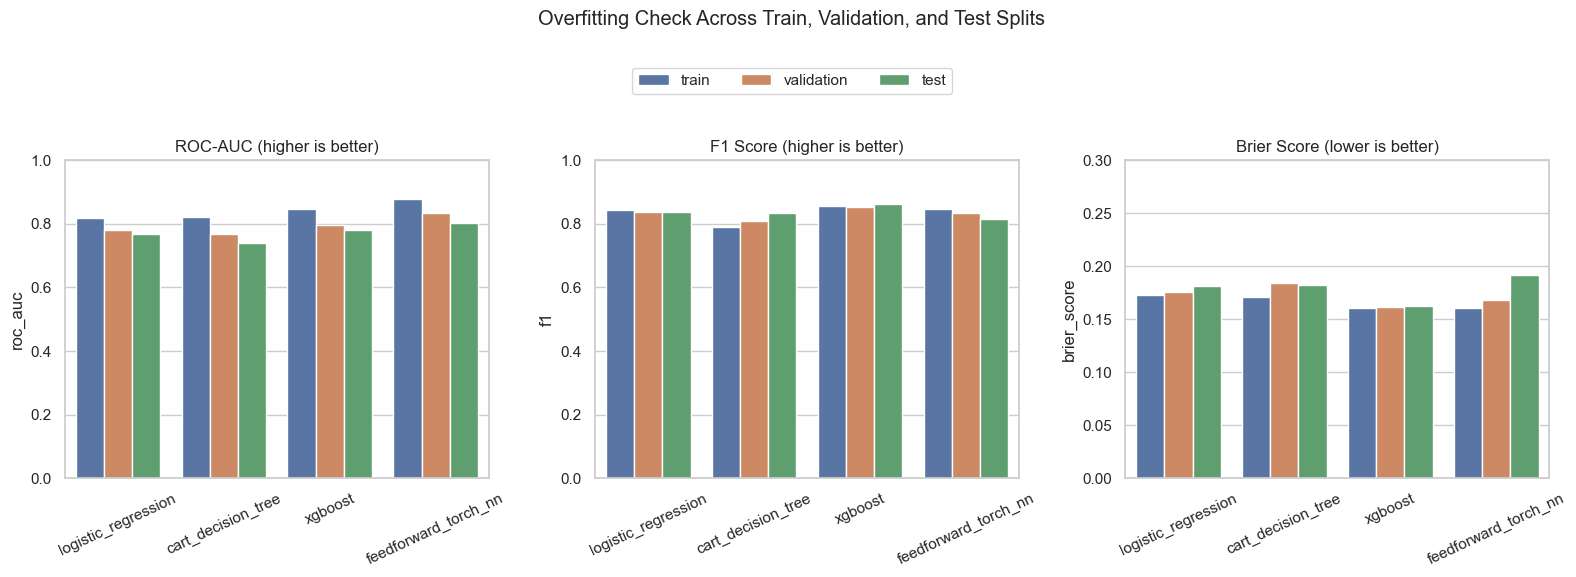

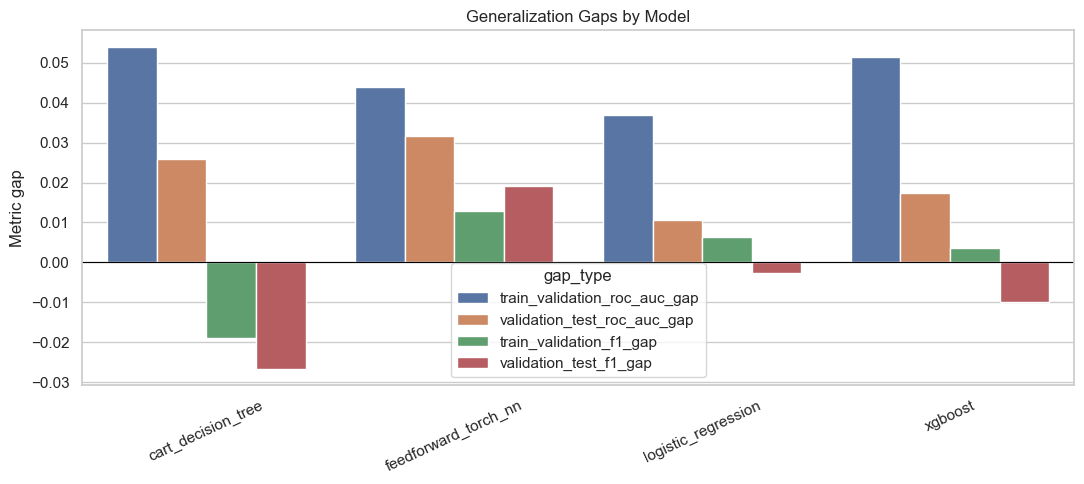

,model,split,roc_auc,balanced_accuracy,f1,mcc,brier_score
0,logistic_regression,train,0.817311,0.736448,0.842500,0.297875,0.172727
1,cart_decision_tree,train,0.821315,0.730842,0.790391,0.273953,0.171373
2,xgboost,train,0.848368,0.761041,0.857700,0.334780,0.160269
3,feedforward_torch_nn,train,0.878597,0.792014,0.847503,0.364199,0.160238
4,logistic_regression,validation,0.780362,0.708813,0.836227,0.351028,0.175461
5,cart_decision_tree,validation,0.767209,0.681658,0.809297,0.297645,0.183767
6,xgboost,validation,0.796981,0.717312,0.854164,0.376334,0.161846
7,feedforward_torch_nn,validation,0.834543,0.744835,0.834534,0.401184,0.168607
8,logistic_regression,test,0.769711,0.692024,0.838824,0.306219,0.181485
9,cart_decision_tree,test,0.741202,0.659955,0.836012,0.259128,0.182038


,model,train_validation_roc_auc_gap,validation_test_roc_auc_gap,train_validation_f1_gap,validation_test_f1_gap,train_validation_brier_score_worsening,validation_test_brier_score_worsening,overfitting_flag
0,cart_decision_tree,0.054106,0.026007,-0.018905,-0.026716,0.012394,-0.001729,Moderate overfitting risk
1,feedforward_torch_nn,0.044054,0.031785,0.012969,0.019137,0.008370,0.023183,Moderate overfitting risk
2,logistic_regression,0.036949,0.010651,0.006273,-0.002597,0.002734,0.006024,Low overfitting risk
3,xgboost,0.051387,0.017320,0.003536,-0.009862,0.001577,0.000548,Moderate overfitting risk


Best validation PR-AUC iteration: 344
Final train-validation PR-AUC gap: 0.04074503187516132


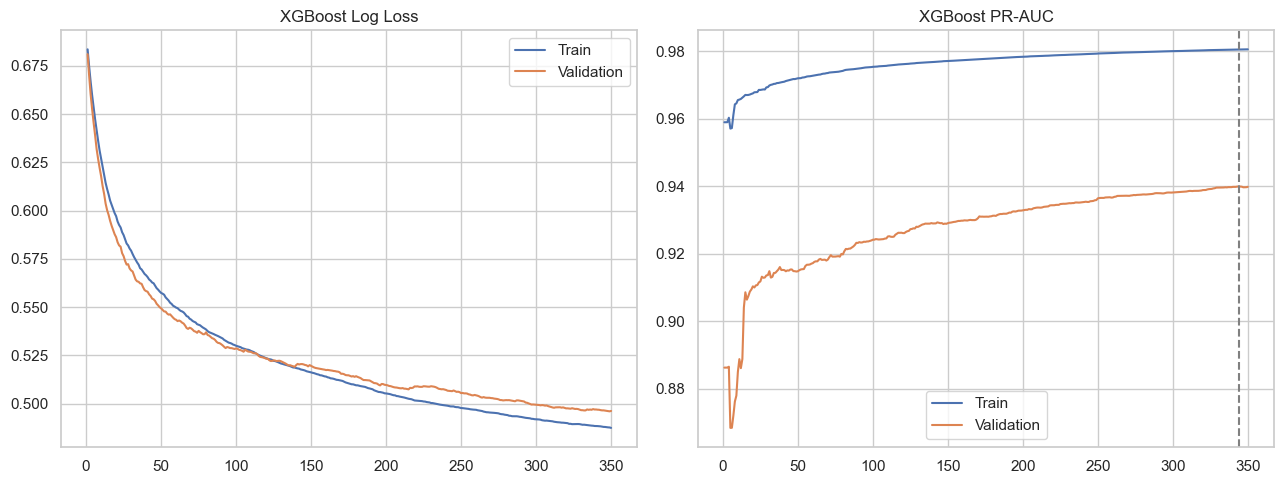

,iteration,train_logloss,valid_logloss,train_aucpr,valid_aucpr
345,346,0.487948,0.496408,0.980584,0.939925
346,347,0.487818,0.496292,0.980607,0.939747
347,348,0.487736,0.496178,0.980610,0.939767
348,349,0.487687,0.496037,0.980617,0.939779
349,350,0.487471,0.496239,0.980633,0.939888


In [7]:
# -----------------------------
# All-model overfitting check
# -----------------------------
overfit_metric_rows = []
for split, Xs, ys in [("train", X_train, y_train), ("validation", X_valid, y_valid), ("test", X_test, y_test)]:
    for name, model in models.items():
        proba = predict_proba_positive(model, Xs)
        overfit_metric_rows.append(robust_metrics(name, split, ys, proba, 0.50))

overfit_metrics_df = pd.DataFrame(overfit_metric_rows)
save_table(overfit_metrics_df, paths.tables_dir / "model_metrics_with_train.csv")

overfit_rows = []
for name, g in overfit_metrics_df.groupby("model"):
    g = g.set_index("split")
    row = {"model": name}
    for metric in ["roc_auc", "average_precision_success", "balanced_accuracy", "f1", "mcc", "brier_score"]:
        row[f"train_{metric}"] = g.loc["train", metric]
        row[f"validation_{metric}"] = g.loc["validation", metric]
        row[f"test_{metric}"] = g.loc["test", metric]
        if metric == "brier_score":
            # Higher Brier is worse, so positive means validation/test is worse than the earlier split.
            row[f"train_validation_{metric}_worsening"] = g.loc["validation", metric] - g.loc["train", metric]
            row[f"validation_test_{metric}_worsening"] = g.loc["test", metric] - g.loc["validation", metric]
        else:
            # Higher is better, so positive means the earlier split is better than the later split.
            row[f"train_validation_{metric}_gap"] = g.loc["train", metric] - g.loc["validation", metric]
            row[f"validation_test_{metric}_gap"] = g.loc["validation", metric] - g.loc["test", metric]

    auc_gap = row["train_validation_roc_auc_gap"]
    f1_gap = row["train_validation_f1_gap"]
    brier_worse = row["train_validation_brier_score_worsening"]
    if auc_gap > 0.08 or f1_gap > 0.05 or brier_worse > 0.03:
        flag = "High overfitting risk"
    elif auc_gap > 0.04 or f1_gap > 0.02 or brier_worse > 0.01:
        flag = "Moderate overfitting risk"
    else:
        flag = "Low overfitting risk"
    row["overfitting_flag"] = flag
    overfit_rows.append(row)

overfit_check_df = pd.DataFrame(overfit_rows)
save_table(overfit_check_df, paths.tables_dir / "proposal_overfitting_check_all_models.csv")

# Graph 1: train/validation/test comparison for every model.
plot_metrics = ["roc_auc", "f1", "brier_score"]
metric_titles = {
    "roc_auc": "ROC-AUC (higher is better)",
    "f1": "F1 Score (higher is better)",
    "brier_score": "Brier Score (lower is better)",
}
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=False)
for ax, metric in zip(axes, plot_metrics):
    sns.barplot(data=overfit_metrics_df, x="model", y=metric, hue="split", ax=ax)
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=25)
    if metric == "brier_score":
        ax.set_ylim(0, max(0.30, overfit_metrics_df[metric].max() * 1.15))
    else:
        ax.set_ylim(0, 1)
handles, labels = axes[-1].get_legend_handles_labels()
for ax in axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("Overfitting Check Across Train, Validation, and Test Splits", y=1.15)
plt.tight_layout()
plt.savefig(paths.figures_dir / "proposal_overfitting_check_all_models.png", dpi=180, bbox_inches="tight")
plt.show()

# Graph 2: compact gap view for manuscript discussion.
gap_plot_df = overfit_check_df[[
    "model",
    "train_validation_roc_auc_gap",
    "validation_test_roc_auc_gap",
    "train_validation_f1_gap",
    "validation_test_f1_gap",
]].melt(id_vars="model", var_name="gap_type", value_name="gap")
plt.figure(figsize=(11, 5))
sns.barplot(data=gap_plot_df, x="model", y="gap", hue="gap_type")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Generalization Gaps by Model")
plt.ylabel("Metric gap")
plt.xlabel("")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(paths.figures_dir / "proposal_generalization_gaps_all_models.png", dpi=180)
plt.show()

display(overfit_metrics_df[["model", "split", "roc_auc", "balanced_accuracy", "f1", "mcc", "brier_score"]])
display(overfit_check_df[[
    "model",
    "train_validation_roc_auc_gap",
    "validation_test_roc_auc_gap",
    "train_validation_f1_gap",
    "validation_test_f1_gap",
    "train_validation_brier_score_worsening",
    "validation_test_brier_score_worsening",
    "overfitting_flag",
]])

# -----------------------------
# XGBoost-specific learning curve
# -----------------------------
if "xgboost" in models:
    xgb_pipe = models["xgboost"]
    pre = xgb_pipe.named_steps["preprocessor"]
    Xtr = pre.transform(X_train)
    Xva = pre.transform(X_valid)
    xgb_model = xgb_pipe.named_steps["model"]
    curve_params = xgb_model.get_params()
    curve_params["eval_metric"] = ["logloss", "aucpr"]
    curve_model = XGBClassifier(**curve_params)
    curve_model.fit(Xtr, y_train, eval_set=[(Xtr, y_train), (Xva, y_valid)], verbose=False)
    ev = curve_model.evals_result()
    train_key, valid_key = list(ev.keys())[0], list(ev.keys())[1]
    xgb_curve_df = pd.DataFrame({
        "iteration": np.arange(1, len(ev[train_key]["logloss"]) + 1),
        "train_logloss": ev[train_key]["logloss"],
        "valid_logloss": ev[valid_key]["logloss"],
        "train_aucpr": ev[train_key]["aucpr"],
        "valid_aucpr": ev[valid_key]["aucpr"],
    })
    save_table(xgb_curve_df, paths.tables_dir / "proposal_xgboost_learning_curves.csv")
    best_auc_iter = int(xgb_curve_df.loc[xgb_curve_df.valid_aucpr.idxmax(), "iteration"])
    final_gap = float(xgb_curve_df.iloc[-1].train_aucpr - xgb_curve_df.iloc[-1].valid_aucpr)
    print("Best validation PR-AUC iteration:", best_auc_iter)
    print("Final train-validation PR-AUC gap:", final_gap)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(xgb_curve_df.iteration, xgb_curve_df.train_logloss, label="Train")
    axes[0].plot(xgb_curve_df.iteration, xgb_curve_df.valid_logloss, label="Validation")
    axes[0].set_title("XGBoost Log Loss")
    axes[0].legend()
    axes[1].plot(xgb_curve_df.iteration, xgb_curve_df.train_aucpr, label="Train")
    axes[1].plot(xgb_curve_df.iteration, xgb_curve_df.valid_aucpr, label="Validation")
    axes[1].axvline(best_auc_iter, linestyle="--", color="gray")
    axes[1].set_title("XGBoost PR-AUC")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(paths.figures_dir / "proposal_xgboost_learning_curves.png", dpi=180)
    plt.show()
    display(xgb_curve_df.tail())

## 8. ROC and Precision-Recall Curves

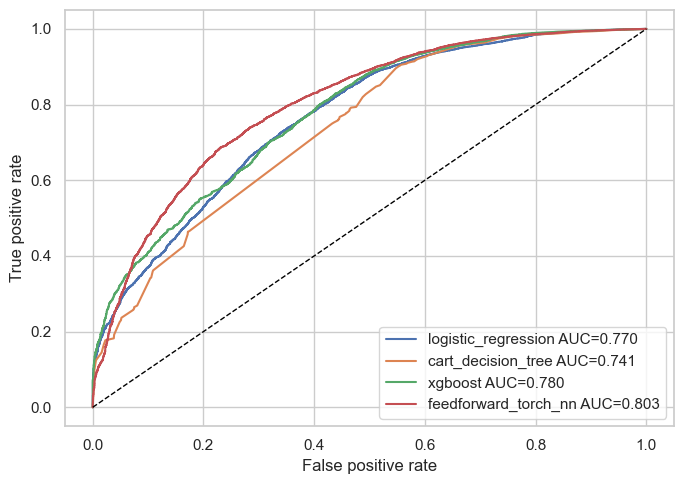

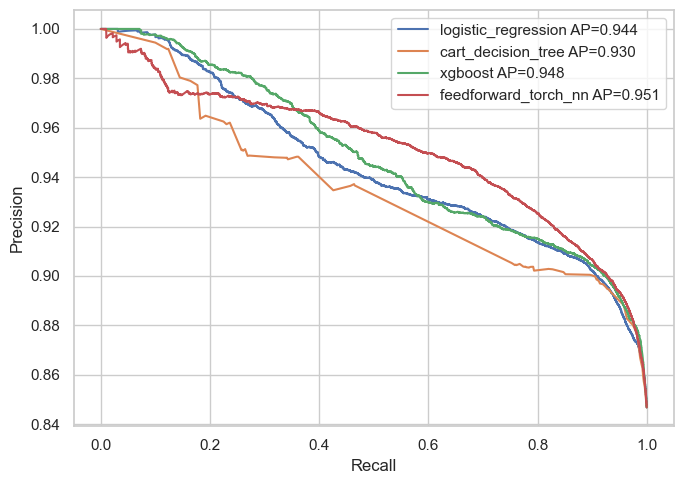

In [8]:
plot_roc_pr_curves(models, X_test, y_test, paths.figures_dir)

## 9. Subgroup Error Disparity Analysis

Algorithmic bias is operationalized as uneven false-positive and false-negative behavior across geopolitical and tactical subgroups. This is model-behavior analysis, not a causal claim about any region or group.

In [9]:
subgroup_columns = ["region_txt", "country_txt", "attacktype1_txt", "targtype1_txt", "weaptype1_txt"]
subgroup_frames = []
for name, model in models.items():
    subgroup_frames.append(subgroup_error_analysis(name, model, X_test, y_test, subgroup_columns, threshold=0.50))
subgroup_df = pd.concat(subgroup_frames, ignore_index=True)
save_table(subgroup_df, paths.tables_dir / "subgroup_error_analysis.csv")

disparity_rows = []
large_groups = subgroup_df[subgroup_df.n >= 200]
for (model_name, subgroup_column), g in large_groups.groupby(["model", "subgroup_column"]):
    disparity_rows.append({
        "model": model_name,
        "subgroup_column": subgroup_column,
        "n_groups": g.group.nunique(),
        "false_positive_rate_gap": g.false_positive_rate.max() - g.false_positive_rate.min(),
        "false_negative_rate_gap": g.false_negative_rate.max() - g.false_negative_rate.min(),
    })
disparity_summary_df = pd.DataFrame(disparity_rows)
save_table(disparity_summary_df, paths.tables_dir / "proposal_subgroup_disparity_summary.csv")

display(subgroup_df.sort_values("false_negative_rate", ascending=False).head(15))
display(disparity_summary_df.sort_values("false_negative_rate_gap", ascending=False))

,model,subgroup_column,group,n,base_success_rate,false_positive_rate,false_negative_rate,tp,fp,tn,fn
248,xgboost,targtype1_txt,Unknown,1438,0.321280,0.000000,1.000000,0,0,976,462
162,cart_decision_tree,targtype1_txt,Unknown,1438,0.321280,0.000000,1.000000,0,0,976,462
138,cart_decision_tree,attacktype1_txt,Assassination,2615,0.635564,0.000000,1.000000,0,0,953,1662
76,logistic_regression,targtype1_txt,Unknown,1438,0.321280,0.000000,1.000000,0,0,976,462
334,feedforward_torch_nn,targtype1_txt,Unknown,1438,0.321280,0.010246,0.991342,4,10,966,458
224,xgboost,attacktype1_txt,Assassination,2615,0.635564,0.008395,0.941637,97,8,945,1565
310,feedforward_torch_nn,attacktype1_txt,Assassination,2615,0.635564,0.011542,0.941637,97,11,942,1565
257,xgboost,weaptype1_txt,Vehicle (not to include vehicle-borne explosiv...,55,0.600000,0.000000,0.939394,2,0,22,31
25,logistic_regression,country_txt,Israel,296,0.706081,0.034483,0.928230,15,3,84,194
111,cart_decision_tree,country_txt,Israel,296,0.706081,0.022989,0.913876,18,2,85,191


,model,subgroup_column,n_groups,false_positive_rate_gap,false_negative_rate_gap
0,cart_decision_tree,attacktype1_txt,7,0.960784,0.977814
15,xgboost,attacktype1_txt,7,0.945839,0.931372
11,logistic_regression,country_txt,25,0.931034,0.928230
3,cart_decision_tree,targtype1_txt,15,0.811663,0.913194
8,feedforward_torch_nn,targtype1_txt,15,0.510881,0.911481
18,xgboost,targtype1_txt,15,0.775414,0.902778
13,logistic_regression,targtype1_txt,15,0.714286,0.883269
5,feedforward_torch_nn,attacktype1_txt,7,0.473943,0.876710
1,cart_decision_tree,country_txt,25,0.938550,0.845382
10,logistic_regression,attacktype1_txt,7,0.775352,0.843439


## 10. Interpretability: Logistic Coefficients and XGBoost Feature Importance / SHAP

Logistic coefficients show the linear baseline's global assumptions. XGBoost feature importance or SHAP summarizes nonlinear tree reliance on transformed features.

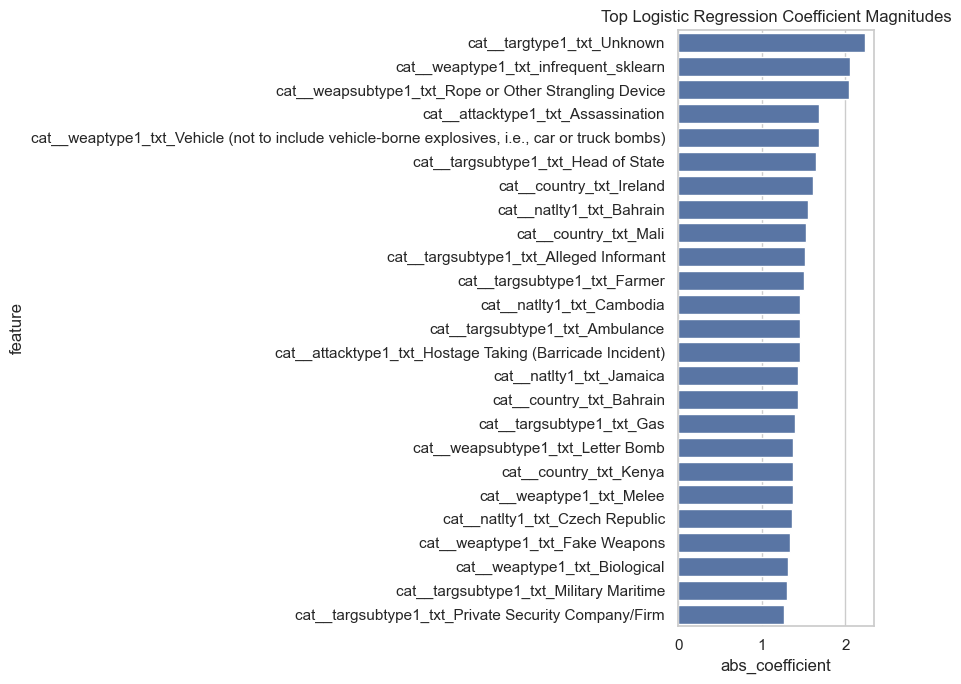

,feature,coefficient,abs_coefficient
198,cat__targtype1_txt_Unknown,-2.231155,2.231155
462,cat__weaptype1_txt_infrequent_sklearn,-2.055709,2.055709
484,cat__weapsubtype1_txt_Rope or Other Strangling...,2.044414,2.044414
171,cat__attacktype1_txt_Assassination,-1.685174,1.685174
461,cat__weaptype1_txt_Vehicle (not to include veh...,1.683652,1.683652
229,cat__targsubtype1_txt_Head of State,-1.647269,1.647269
85,cat__country_txt_Ireland,-1.611515,1.611515
319,cat__natlty1_txt_Bahrain,-1.555627,1.555627
106,cat__country_txt_Mali,1.528064,1.528064
205,cat__targsubtype1_txt_Alleged Informant,1.513821,1.513821


c:\Users\Paulo Tumabing\.conda\envs\ml-course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


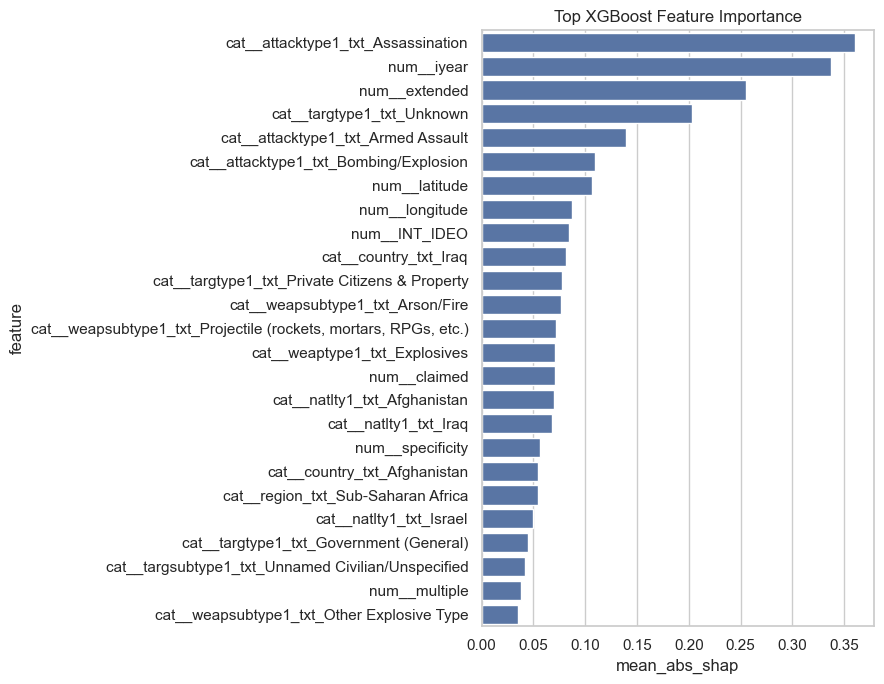

,feature,mean_abs_shap
171,cat__attacktype1_txt_Assassination,0.360656
0,num__iyear,0.337487
3,num__extended,0.255145
198,cat__targtype1_txt_Unknown,0.203464
170,cat__attacktype1_txt_Armed Assault,0.139643
172,cat__attacktype1_txt_Bombing/Explosion,0.109249
4,num__latitude,0.106934
5,num__longitude,0.087652
15,num__INT_IDEO,0.084462
84,cat__country_txt_Iraq,0.082007


In [10]:
def feature_names(pipeline):
    return list(pipeline.named_steps["preprocessor"].get_feature_names_out())

if "logistic_regression" in models:
    lr = models["logistic_regression"]
    lr_importance = pd.DataFrame({
        "feature": feature_names(lr),
        "coefficient": lr.named_steps["model"].coef_.ravel(),
    })
    lr_importance["abs_coefficient"] = lr_importance.coefficient.abs()
    lr_importance = lr_importance.sort_values("abs_coefficient", ascending=False).head(25)
    save_table(lr_importance, paths.tables_dir / "proposal_logistic_coefficients.csv")
    plt.figure(figsize=(9, 7))
    sns.barplot(data=lr_importance, x="abs_coefficient", y="feature")
    plt.title("Top Logistic Regression Coefficient Magnitudes")
    plt.tight_layout()
    plt.savefig(paths.figures_dir / "importance_logistic_regression.png", dpi=180)
    plt.show()
    display(lr_importance)

if "xgboost" in models:
    xgb = models["xgboost"]
    features = feature_names(xgb)
    xgb_model = xgb.named_steps["model"]
    if RUN_SHAP:
        try:
            import shap
            sample = X_test.sample(min(len(X_test), SHAP_SAMPLE_SIZE), random_state=RANDOM_STATE)
            transformed = xgb.named_steps["preprocessor"].transform(sample)
            shap_values = shap.TreeExplainer(xgb_model).shap_values(transformed)
            xgb_importance = pd.DataFrame({"feature": features, "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
            x_axis = "mean_abs_shap"
        except Exception as exc:
            print("SHAP unavailable/failed; using built-in importance:", exc)
            xgb_importance = pd.DataFrame({"feature": features, "importance": xgb_model.feature_importances_})
            x_axis = "importance"
    else:
        xgb_importance = pd.DataFrame({"feature": features, "importance": xgb_model.feature_importances_})
        x_axis = "importance"
    xgb_importance = xgb_importance.sort_values(x_axis, ascending=False).head(25)
    save_table(xgb_importance, paths.tables_dir / "proposal_xgboost_importance.csv")
    plt.figure(figsize=(9, 7))
    sns.barplot(data=xgb_importance, x=x_axis, y="feature")
    plt.title("Top XGBoost Feature Importance")
    plt.tight_layout()
    plt.savefig(paths.figures_dir / "importance_xgboost.png", dpi=180)
    plt.show()
    display(xgb_importance)

## 11. Robustness Checks: Strict Features and Feature-Group Ablations

Strict-feature analysis removes potentially coding-time variables. Feature-group ablations show whether XGBoost depends more on geography, time, or tactical variables.

In [11]:
STRICT_DROP = ["extended", "claimed", "doubtterr"]
FEATURE_GROUPS_TO_DROP = {
    "drop_geography": ["region_txt", "country_txt", "latitude", "longitude", "natlty1_txt"],
    "drop_time": ["iyear", "imonth", "iday"],
    "drop_tactical_attack_target_weapon": ["attacktype1_txt", "targtype1_txt", "targsubtype1_txt", "weaptype1_txt", "weapsubtype1_txt"],
    "drop_uncertainty_claim": ["doubtterr", "guncertain1", "claimed"],
}

def train_xgb_with_drops(label, drop_cols):
    keep_numeric = [c for c in numeric_features if c not in drop_cols]
    keep_categorical = [c for c in categorical_features if c not in drop_cols]
    keep = keep_numeric + keep_categorical
    pos, neg = max(int((y_train == 1).sum()), 1), max(int((y_train == 0).sum()), 1)
    model = Pipeline([
        ("preprocessor", make_preprocessor(keep_numeric, keep_categorical)),
        ("model", XGBClassifier(
            n_estimators=350, max_depth=4, learning_rate=0.05, subsample=0.85,
            colsample_bytree=0.85, objective="binary:logistic", eval_metric="logloss",
            scale_pos_weight=neg / pos, random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
        )),
    ])
    model.fit(X_train[keep], y_train)
    rows = []
    for split, Xs, ys in [("validation", X_valid[keep], y_valid), ("test", X_test[keep], y_test)]:
        rows.append(robust_metrics(label, split, ys, predict_proba_positive(model, Xs), 0.50))
    return rows

strict_rows = train_xgb_with_drops("strict_xgboost", STRICT_DROP)
strict_df = pd.DataFrame(strict_rows)
strict_df["dropped_columns"] = ", ".join(STRICT_DROP)
save_table(strict_df, paths.tables_dir / "proposal_strict_feature_audit.csv")

ablation_rows = []
for split, Xs, ys in [("validation", X_valid, y_valid), ("test", X_test, y_test)]:
    ablation_rows.append(robust_metrics("xgboost_full_feature_set", split, ys, predict_proba_positive(models["xgboost"], Xs), 0.50))
for label, drops in FEATURE_GROUPS_TO_DROP.items():
    print("Running ablation:", label)
    ablation_rows.extend(train_xgb_with_drops(f"xgboost_{label}", drops))
ablation_df = pd.DataFrame(ablation_rows)
save_table(ablation_df, paths.tables_dir / "proposal_feature_group_ablation.csv")

display(strict_df)
display(ablation_df.sort_values(["split", "roc_auc"], ascending=[True, False]))

Running ablation: drop_geography
Running ablation: drop_time
Running ablation: drop_tactical_attack_target_weapon
Running ablation: drop_uncertainty_claim


,model,split,roc_auc,average_precision_success,average_precision_failure,brier_score,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,mcc,dropped_columns
0,strict_xgboost,validation,0.788013,0.935610,0.562594,0.165376,0.5,0.771805,0.711215,0.904633,0.806271,0.852625,0.383841,0.193729,26769,2822,4530,6432,0.366444,"extended, claimed, doubtterr"
1,strict_xgboost,test,0.772007,0.942951,0.472392,0.164123,0.5,0.781867,0.692207,0.912215,0.821464,0.864464,0.437051,0.178536,22113,2128,2741,4806,0.325376,"extended, claimed, doubtterr"


,model,split,roc_auc,average_precision_success,average_precision_failure,brier_score,threshold,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,mcc
3,xgboost_drop_geography,test,0.783395,0.948021,0.472746,0.170276,0.5,0.790487,0.688128,0.909554,0.835692,0.871060,0.459437,0.164308,22496,2237,2632,4423,0.326095
1,xgboost_full_feature_set,test,0.779661,0.947605,0.478004,0.162394,0.5,0.781427,0.693966,0.912982,0.820053,0.864026,0.432122,0.179947,22075,2104,2765,4844,0.327432
5,xgboost_drop_time,test,0.778626,0.946331,0.476596,0.145321,0.5,0.815717,0.691164,0.907890,0.870723,0.888918,0.488396,0.129277,23439,2378,2491,3480,0.352540
9,xgboost_drop_uncertainty_claim,test,0.775681,0.946042,0.474321,0.164012,0.5,0.778973,0.694451,0.913490,0.816301,0.862165,0.427398,0.183699,21974,2081,2788,4945,0.326448
7,xgboost_drop_tactical_attack_target_weapon,test,0.648324,0.907804,0.261802,0.229730,0.5,0.629546,0.610430,0.894246,0.637988,0.744688,0.417129,0.362012,17174,2031,2838,9745,0.162654
0,xgboost_full_feature_set,validation,0.796981,0.939900,0.567509,0.161846,0.5,0.774419,0.717312,0.907305,0.806903,0.854164,0.372280,0.193097,26790,2737,4615,6411,0.376334
2,xgboost_drop_geography,validation,0.795908,0.938568,0.566292,0.171105,0.5,0.762311,0.697369,0.899221,0.799253,0.846295,0.404516,0.200747,26536,2974,4378,6665,0.341632
4,xgboost_drop_time,validation,0.792264,0.937094,0.570438,0.146667,0.5,0.809237,0.718350,0.901618,0.860938,0.880809,0.424238,0.139062,28584,3119,4233,4617,0.407323
8,xgboost_drop_uncertainty_claim,validation,0.790276,0.937354,0.564956,0.165599,0.5,0.767514,0.711877,0.905780,0.799163,0.849138,0.375408,0.200837,26533,2760,4592,6668,0.364537
6,xgboost_drop_tactical_attack_target_weapon,validation,0.636072,0.885423,0.297810,0.235429,0.5,0.624023,0.596499,0.866079,0.639680,0.735859,0.446681,0.360320,21238,3284,4068,11963,0.152081


## 12. Bootstrap Confidence Intervals and Calibration

Confidence intervals quantify uncertainty. Calibration curves test whether model scores are meaningful for threshold-based decisions.

,model,metric,point_estimate,ci_lower_95,ci_upper_95
0,logistic_regression,roc_auc,0.769711,0.762802,0.777403
1,logistic_regression,average_precision_success,0.943835,0.941135,0.946281
2,logistic_regression,average_precision_failure,0.455160,0.442472,0.472240
3,logistic_regression,balanced_accuracy,0.692024,0.685245,0.699850
4,logistic_regression,mcc,0.306219,0.294494,0.318639
5,cart_decision_tree,roc_auc,0.741202,0.734331,0.748395
6,cart_decision_tree,average_precision_success,0.929746,0.926872,0.932519
7,cart_decision_tree,average_precision_failure,0.420563,0.406030,0.434106
8,cart_decision_tree,balanced_accuracy,0.659955,0.653272,0.666907
9,cart_decision_tree,mcc,0.259128,0.247652,0.270613


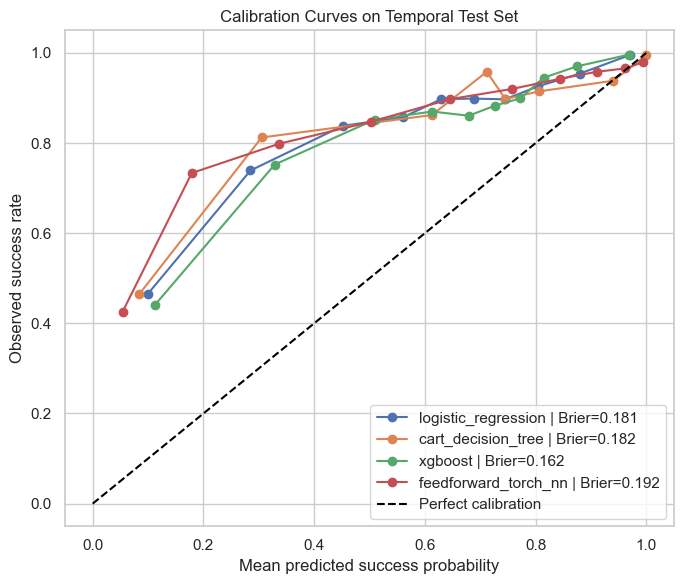

,model,bin,mean_predicted_probability,observed_success_rate,brier_score
0,logistic_regression,1,0.099111,0.464612,0.181485
1,logistic_regression,2,0.285047,0.739226,0.181485
2,logistic_regression,3,0.451882,0.838314,0.181485
3,logistic_regression,4,0.560793,0.857458,0.181485
4,logistic_regression,5,0.629541,0.897452,0.181485
5,logistic_regression,6,0.688388,0.898710,0.181485
6,logistic_regression,7,0.744913,0.897105,0.181485
7,logistic_regression,8,0.804025,0.925763,0.181485
8,logistic_regression,9,0.879750,0.954074,0.181485
9,logistic_regression,10,0.970700,0.995596,0.181485


In [12]:
from sklearn.calibration import calibration_curve

N_BOOTSTRAP = 300
rng = np.random.default_rng(RANDOM_STATE)

def bootstrap_ci(name, y_true, proba, threshold=0.50):
    y_arr, p_arr = np.asarray(y_true), np.asarray(proba)
    rows = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, len(y_arr), len(y_arr))
        if len(np.unique(y_arr[idx])) < 2:
            continue
        rows.append(robust_metrics(name, "bootstrap", y_arr[idx], p_arr[idx], threshold))
    boot = pd.DataFrame(rows)
    point = robust_metrics(name, "test", y_arr, p_arr, threshold)
    metrics = ["roc_auc", "average_precision_success", "average_precision_failure", "balanced_accuracy", "mcc"]
    return pd.DataFrame([{
        "model": name,
        "metric": m,
        "point_estimate": point[m],
        "ci_lower_95": boot[m].quantile(0.025),
        "ci_upper_95": boot[m].quantile(0.975),
    } for m in metrics])

ci_df = pd.concat([bootstrap_ci(name, y_test, predict_proba_positive(model, X_test)) for name, model in models.items()], ignore_index=True)
save_table(ci_df, paths.tables_dir / "proposal_bootstrap_confidence_intervals.csv")
display(ci_df)

calibration_rows = []
plt.figure(figsize=(7, 6))
for name, model in models.items():
    proba = predict_proba_positive(model, X_test)
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    brier = brier_score_loss(y_test, proba)
    for i, (mp, fp) in enumerate(zip(mean_pred, frac_pos), 1):
        calibration_rows.append({"model": name, "bin": i, "mean_predicted_probability": mp, "observed_success_rate": fp, "brier_score": brier})
    plt.plot(mean_pred, frac_pos, marker="o", label=f"{name} | Brier={brier:.3f}")
plt.plot([0, 1], [0, 1], "--", color="black", label="Perfect calibration")
plt.xlabel("Mean predicted success probability")
plt.ylabel("Observed success rate")
plt.title("Calibration Curves on Temporal Test Set")
plt.legend()
plt.tight_layout()
plt.savefig(paths.figures_dir / "proposal_calibration_curves.png", dpi=180)
plt.show()
calibration_df = pd.DataFrame(calibration_rows)
save_table(calibration_df, paths.tables_dir / "proposal_calibration_curves.csv")
display(calibration_df)

## 13. Final Manuscript Summary

The notebook saves models, figures, and tables needed for the paper. Use the tables below to write the results section: main metrics, threshold analysis, subgroup disparities, interpretability, ablations, and confidence intervals. The added model in this version is `cart_decision_tree`.


In [13]:
important_tables = [
    "model_metrics.csv",
    "model_metrics_with_train.csv",
    "proposal_validation_selected_thresholds.csv",
    "threshold_simulation_results.csv",
    "subgroup_error_analysis.csv",
    "proposal_subgroup_disparity_summary.csv",
    "proposal_xgboost_importance.csv",
    "proposal_logistic_coefficients.csv",
    "proposal_strict_feature_audit.csv",
    "proposal_feature_group_ablation.csv",
    "proposal_bootstrap_confidence_intervals.csv",
    "proposal_calibration_curves.csv",
    "proposal_overfitting_check_all_models.csv",
]
print("Saved models to:", paths.models_dir)
print("Saved figures to:", paths.figures_dir)
print("Saved tables to:", paths.tables_dir)
for table in important_tables:
    print(" -", paths.tables_dir / table)
print("Notebook complete.")

Saved models to: c:\Documents\Compsci\CSELEC2C\Project\models
Saved figures to: c:\Documents\Compsci\CSELEC2C\Project\results\figures
Saved tables to: c:\Documents\Compsci\CSELEC2C\Project\results\tables
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\model_metrics.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\model_metrics_with_train.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_validation_selected_thresholds.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\threshold_simulation_results.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\subgroup_error_analysis.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_subgroup_disparity_summary.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_xgboost_importance.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_logistic_coefficients.csv
 - c:\Documents\Compsci\CSELEC2C\Project\results\tables\proposal_strict_feature_audit.csv